# How To: Assess Image Quality Before Pipeline Design

Run diagnostics on a plate image to objectively assess noise, contrast,
and structure before choosing enhancers and detectors.

In [1]:
from phenotypic.data import load_yeast_plate
import matplotlib.pyplot as plt

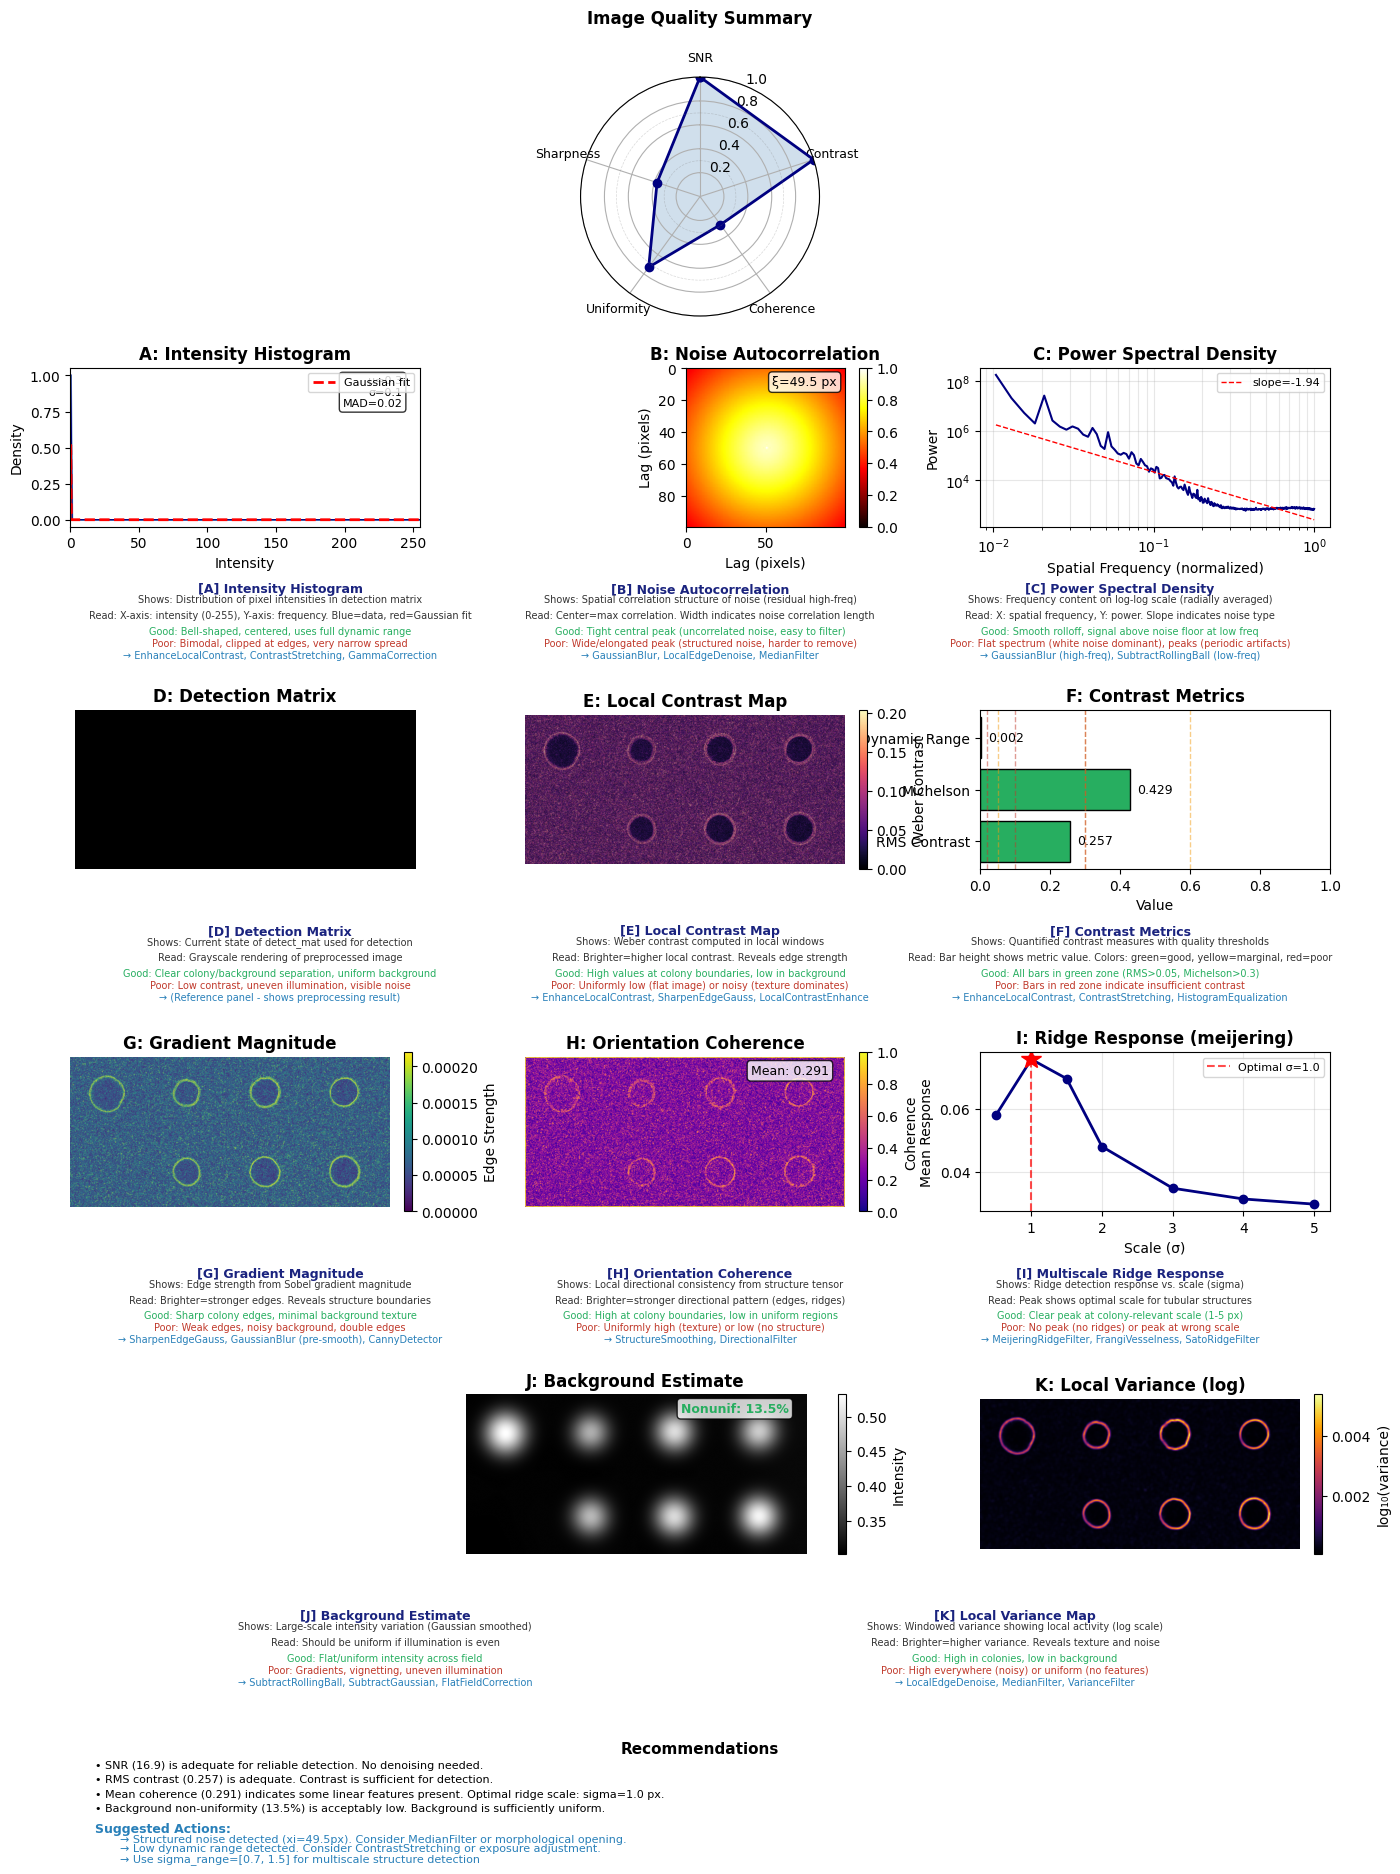

In [2]:
plate = load_yeast_plate()
fig, metrics = plate.plot.diagnostics()

## Decision Guide

| Metric | Threshold | Action |
|--------|-----------|--------|
| Low SNR (< 10) | Noisy image | Add `StableDenoise` or `GaussianBlur` |
| Low RMS contrast | Faint colonies | Add `CLAHE` or `ContrastStretching` |
| Low dynamic range | Under-exposed | Add `ContrastStretching` |
| Low gradient mean | Soft edges | Add `UnsharpMask` or `SobelFilter` |
| Long correlation length | Uneven illumination | Add `HomomorphicFilter` |

In [3]:
for category, values in metrics.items():
    if not isinstance(values, dict):
        print(f"\n{category}: {values}")
        continue
    print(f"\n{category}:")
    for key, val in values.items():
        if isinstance(val, (int, float)):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")


bit_depth: 8

noise:
  snr: 16.8730
  sigma_mad: 0.0197
  correlation_length: 49.5000

contrast:
  rms_contrast: 0.2567
  michelson: 0.4287
  dynamic_range: 0.0022
  p1: 0.2520
  p99: 0.6302

structure:
  mean_coherence: 0.2913
  optimal_scale: 1.0000
  peak_response: 0.0756
  ridge_responses: [0.05793954597949425, 0.07563562746120774, 0.06950455411210275, 0.04796233905052049, 0.03477529585227895, 0.03136497347531455, 0.02972701492659689]
  scales: [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
  ridge_method: meijering

background:
  nonuniformity_ratio: 0.1346
  mean_gradient: 0.0005

quality_scores:
  SNR: 1.0000
  Contrast: 1.0000
  Coherence: 0.2913
  Uniformity: 0.7307
  Sharpness: 0.3782

interpretations:
  noise: SNR (16.9) is adequate for reliable detection. No denoising needed.
  contrast: RMS contrast (0.257) is adequate. Contrast is sufficient for detection.
  structure: Mean coherence (0.291) indicates some linear features present. Optimal ridge scale: sigma=1.0 px.
  background: Ba

In [4]:
plt.close("all")